In [607]:
import numpy as np
import pandas as pd

# 设置随机种子
np.random.seed(42)

# 生成400个样本
n_samples = 400

# 生成特征
# 1. 房屋面积 (平方米)
area = np.random.uniform(50, 200, n_samples)

# 2. 卧室数量
bedrooms = np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.1, 0.3, 0.4, 0.15, 0.05])

# 3. 房龄 (年)
age = np.random.exponential(10, n_samples)
age = np.clip(age, 0, 50)  # 限制在0-50年

# 4. 地理位置评分 (1-10分)
location = np.random.normal(6, 2, n_samples)
location = np.clip(location, 1, 10)

# 生成目标变量：房价 (万元)
# 真实关系：price = 0.8*area + 15*bedrooms - 0.5*age + 8*location + 30 + noise
noise = np.random.normal(0, 20, n_samples)
price = 0.8 * area + 15 * bedrooms - 0.5 * age + 8 * location + 30 + noise

# 创建DataFrame
data = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'location': location,
    'price': price
})

In [608]:
data.head()

,area,bedrooms,age,location,price
0,106.181018,2,12.283975,9.131048,187.657317
1,192.607146,4,1.655105,5.868499,302.204735
2,159.799091,3,8.587021,4.889601,268.277586
3,139.798773,4,9.332209,9.762314,299.646664
4,73.402796,2,5.518745,3.103972,136.525785


In [620]:
rng=np.random.default_rng(17)

data_train=data.sample(frac=0.67,random_state=rng)
data_test=data.sample(frac=0.33,random_state=rng)

In [621]:
STD=data_train.std(axis=0)
MEAN=data_train.mean(axis=0)
STD,MEAN

(area        45.179373
 bedrooms     0.985983
 age          9.421287
 location     1.918309
 price       46.788658
 dtype: float64,
 area        121.827557
 bedrooms      2.723881
 age           9.470029
 location      6.058612
 price       214.852342
 dtype: float64)

In [622]:
data_normalized=(data_train-MEAN)/STD

In [623]:
test_normalized=(data_test-MEAN)/STD

In [624]:
import torch
from torch import nn

In [656]:
X=torch.tensor(data_normalized.iloc[:,:-1].values,dtype=torch.float64)
y=torch.tensor(data_normalized.iloc[:,-1].values.reshape(-1,1),dtype=torch.float64)

In [657]:
X_test=torch.tensor(test_normalized.iloc[:,:-1].values)
y_test=torch.tensor(test_normalized.iloc[:,-1].values.reshape(-1,1))

In [658]:
X[:3],y[:3]

(tensor([[ 1.1234, -1.7484,  0.2325,  0.1263],
         [-0.3079,  0.2800,  0.8030,  0.8436],
         [-0.9269,  0.2800, -0.5539, -0.1162]], dtype=torch.float64),
 tensor([[ 0.2380],
         [-0.5886],
         [-0.9161]], dtype=torch.float64))

In [854]:
net=nn.Sequential(nn.Linear(4,7,dtype=torch.float64),
                  nn.PReLU(dtype=torch.float64),  #发现使用ReLU最后得到的图像左端是水平的,因此进行改动
                  nn.Linear(7,1,dtype=torch.float64),
                 )
#这里默认是float32,而我前面是float64(double)

def init_weights(m):
    if type(m)==nn.Linear:
        nn.init.normal_(m.weight,std=0.01,)

net.apply(init_weights)

Sequential(
  (0): Linear(in_features=4, out_features=7, bias=True)
  (1): PReLU(num_parameters=1)
  (2): Linear(in_features=7, out_features=1, bias=True)
)

In [855]:
loss=nn.MSELoss(reduction='none') #这里loss实现的就是后面写的error函数的作用,所以事实上不需要写error
#MSELoss均方误差

In [856]:
trainer=torch.optim.SGD(net.parameters(),lr=0.1)

In [857]:
def error(y_hat,y):
    return (abs(y_hat-y).sum())/y.shape[0]  #y.shape[0]比len(y)快


In [858]:
def train_epoch(net,X,y,updater,loss):
    if isinstance(net,torch.nn.Module):
        net.train()
        
    #for i in range(0,y.shape[0],100):
        #y_hat=net(X[i:i+100])
        #l=loss(y_hat,y[i:i+100])

        y_hat=net(X)
        l=loss(y_hat,y)
        
        updater.zero_grad()
        l.mean().backward() #因为前面loss那里reduction='none',所以这里有.mean()
        #l.backward()
        updater.step()
    
    return 0
    

In [883]:
for i in range(20):
    train_epoch(net,X,y,trainer,loss)
    print(float(loss(net(X),y).mean()))
    
y_test_hat=net(X_test)
loss(y_test_hat,y_test).mean()

0.19261476171412215
0.19242453134444384
0.19224153832418592
0.19206538277015173
0.19189581465209593
0.19173253957948502
0.191575157731485
0.19142348714414772
0.19127716606640638
0.19113595948204942
0.19099963897582228
0.19086844573900205
0.19074171864455322
0.19061926445385663
0.1905009050445498
0.19038651346416338
0.1902758808927704
0.1901688556343639
0.19006529379281079
0.1899650586777988


tensor(0.1650, dtype=torch.float64, grad_fn=<MeanBackward0>)

----

In [884]:
y_test_hat=net(X_test)
loss(y_test_hat,y_test).mean()

tensor(0.1650, dtype=torch.float64, grad_fn=<MeanBackward0>)

In [885]:
test=pd.DataFrame({'test_hat':y_test_hat.reshape(-1).detach().numpy(),
                   'test':y_test.reshape(-1).numpy(),
                  })

In [886]:
test.head()

,test_hat,test
0,-0.630977,-0.653501
1,-0.234972,0.225856
2,-0.183713,-0.399532
3,1.574720,2.310513
4,-1.022750,-1.252730


In [887]:
final_test=test*STD[-1]+MEAN[-1]
final_test.head()

,test_hat,test
0,185.329778,184.275918
1,203.858315,225.419840
2,206.256661,196.158783
3,288.531365,322.958123
4,166.999219,156.238809


In [888]:
error(final_test['test_hat'],final_test['test'])

15.579129901313895

In [889]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: xlabel='test', ylabel='test_hat'>

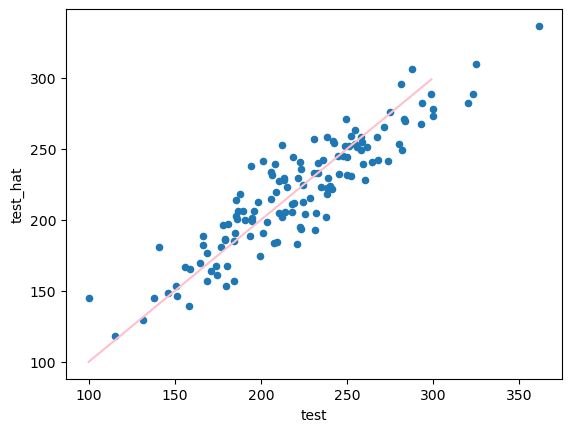

In [890]:
final_test.plot(kind='scatter',x='test',y='test_hat')
standard=pd.Series(np.arange(100,300),index=np.arange(100,300))
standard.plot.line(color='pink')

<mark>conclusion: 从d2l中根据需求去修改比自己写应该会方便且不容易错</mark>

前面写的挺难看的,后面闲了改一下...